# Sentiment Analysis of Drug Reviews Using Natural Language Processing Techniques

## Problem Statement:

This study applies sentiment analysis and textual pattern extraction on drug reviews to identify not only user sentiment but also key factors such as side effects, ineffectiveness, or condition mismatch that contribute to negative medication experiences.

In [2]:
import pandas as pd
import re
import nltk
import string
import html
import matplotlib.pyplot as plt
import numpy as np
#from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

# download NLTK resources (do only once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Basic Data Cleaning

In [ ]:
# #skip if not running on colab
# from google.colab import drive
# drive.mount('/content/drive')

# file_path = '/content/drive/My Drive/SMC-Project/drugsComTrain_raw.tsv'
# df = pd.read_csv(file_path, sep="\t")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Have basic understanding and cleaning of the data.

In [ ]:
#df = pd.read_csv('drugsComTrain_raw.tsv' , sep='\t')
df = pd.read_csv('drugsComTrain_raw.tsv', sep='\t', on_bad_lines='skip')

df.head()

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,"May 20, 2012",27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,"November 27, 2016",37


In [5]:
df.tail()

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10.0,"May 31, 2015",125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1.0,"November 1, 2011",34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2.0,"March 15, 2014",35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10.0,"September 19, 2015",79
161296,215220,Lubiprostone,"Constipation, Chronic","""I&#039;ve had chronic constipation all my adu...",9.0,"December 13, 2014",116


In [6]:
#Basic checks
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   161297 non-null  int64  
 1   drugName     161297 non-null  object 
 2   condition    160398 non-null  object 
 3   review       161297 non-null  object 
 4   rating       161297 non-null  float64
 5   date         161297 non-null  object 
 6   usefulCount  161297 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 8.6+ MB


In [7]:
#Check for missing values
df.isna().sum()


,0
Unnamed: 0,0
drugName,0
condition,899
review,0
rating,0
date,0
usefulCount,0


In [8]:
#Remove missing values as it only contributes to ~0.9% of the data
df.dropna(subset=['condition'], inplace=True)
#Double check for missing values
df.isna().sum()

,0
Unnamed: 0,0
drugName,0
condition,0
review,0
rating,0
date,0
usefulCount,0


In [9]:
#Rename columns
df.rename(columns={'Unnamed: 0': 'patient_id'}, inplace=True)

In [10]:
#Check for duplicates
df.duplicated().sum()

0

In [11]:
#Change date to proper format
df['date'] = pd.to_datetime(df['date'], format='%B %d, %Y')


In [12]:
#Final check
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160398 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   patient_id   160398 non-null  int64         
 1   drugName     160398 non-null  object        
 2   condition    160398 non-null  object        
 3   review       160398 non-null  object        
 4   rating       160398 non-null  float64       
 5   date         160398 non-null  datetime64[ns]
 6   usefulCount  160398 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 9.8+ MB


In [13]:
#Create copy of cleaned data
df2=df.copy()

In [14]:
df2.head()

,patient_id,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,2016-11-27,37


## Part 1 : Sentiment Analysis

### Text Preprocessing

1. Sentence Segmentation

In [15]:
from nltk.tokenize import sent_tokenize

pd.set_option('display.max_colwidth', None)

df2['sentences'] = df2['review'].apply(sent_tokenize)
df2[['sentences']].head()

,sentences
0,"[""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""]"
1,"[""My son is halfway through his fourth week of Intuniv., We became concerned when he began this last week, when he started taking the highest dose he will be on., For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.), I called his doctor on Monday morning and she said to stick it out a few days., See how he did at school, and with getting up in the morning., The last two days have been problem free., He is MUCH more agreeable than ever., He is less emotional (a good thing), less cranky., He is remembering all the things he should., Overall his behavior is better., We have tried many different medications and so far this is the most effective.""]"
2,"[""I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects., But it contained hormone gestodene, which is not available in US, so I switched to Lybrel, because the ingredients are similar., When my other pills ended, I started Lybrel immediately, on my first day of period, as the instructions said., And the period lasted for two weeks., When taking the second pack- same two weeks., And now, with third pack things got even worse- my third period lasted for two weeks and now it&#039;s the end of the third week- I still have daily brown discharge., The positive side is that I didn&#039;t have any other side effects., The idea of being period free was so tempting..., Alas.""]"
3,"[""This is my first time using any form of birth control., I&#039;m glad I went with the patch, I have been on it for 8 months., At first It decreased my libido but that subsided., The only downside is that it made my periods longer (5-6 days to be exact) I used to only have periods for 3-4 days max also made my cramps intense for the first two days of my period, I never had cramps before using birth control., Other than that in happy with the patch""]"
4,"[""Suboxone has completely turned my life around., I feel healthier, I&#039;m excelling at my job and I always have money in my pocket and my savings account., I had none of those before Suboxone and spent years abusing oxycontin., My paycheck was already spent by the time I got it and I started resorting to scheming and stealing to fund my addiction., All that is history., If you&#039;re ready to stop, there&#039;s a good chance that suboxone will put you on the path of great life again., I have found the side-effects to be minimal compared to oxycontin., I&#039;m actually sleeping better., Slight constipation is about it for me., It truly is amazing., The cost pales in comparison to what I spent on oxycontin.""]"


2. Tokenization

In [16]:
df2['tokens'] = df2['review'].apply(word_tokenize)
df2[['tokens']].head()

,tokens
0,"[``, It, has, no, side, effect, ,, I, take, it, in, combination, of, Bystolic, 5, Mg, and, Fish, Oil, '']"
1,"[``, My, son, is, halfway, through, his, fourth, week, of, Intuniv, ., We, became, concerned, when, he, began, this, last, week, ,, when, he, started, taking, the, highest, dose, he, will, be, on, ., For, two, days, ,, he, could, hardly, get, out, of, bed, ,, was, very, cranky, ,, and, slept, for, nearly, 8, hours, on, a, drive, home, from, school, vacation, (, very, unusual, for, him, ., ), I, called, his, doctor, on, Monday, morning, and, she, said, to, stick, it, out, a, few, days, ., See, how, he, did, at, school, ,, and, with, getting, up, in, ...]"
2,"[``, I, used, to, take, another, oral, contraceptive, ,, which, had, 21, pill, cycle, ,, and, was, very, happy-, very, light, periods, ,, max, 5, days, ,, no, other, side, effects, ., But, it, contained, hormone, gestodene, ,, which, is, not, available, in, US, ,, so, I, switched, to, Lybrel, ,, because, the, ingredients, are, similar, ., When, my, other, pills, ended, ,, I, started, Lybrel, immediately, ,, on, my, first, day, of, period, ,, as, the, instructions, said, ., And, the, period, lasted, for, two, weeks, ., When, taking, the, second, pack-, same, two, weeks, ., And, now, ,, ...]"
3,"[``, This, is, my, first, time, using, any, form, of, birth, control, ., I, &, #, 039, ;, m, glad, I, went, with, the, patch, ,, I, have, been, on, it, for, 8, months, ., At, first, It, decreased, my, libido, but, that, subsided, ., The, only, downside, is, that, it, made, my, periods, longer, (, 5-6, days, to, be, exact, ), I, used, to, only, have, periods, for, 3-4, days, max, also, made, my, cramps, intense, for, the, first, two, days, of, my, period, ,, I, never, had, cramps, before, using, birth, control, ., Other, than, that, in, happy, ...]"
4,"[``, Suboxone, has, completely, turned, my, life, around, ., I, feel, healthier, ,, I, &, #, 039, ;, m, excelling, at, my, job, and, I, always, have, money, in, my, pocket, and, my, savings, account, ., I, had, none, of, those, before, Suboxone, and, spent, years, abusing, oxycontin, ., My, paycheck, was, already, spent, by, the, time, I, got, it, and, I, started, resorting, to, scheming, and, stealing, to, fund, my, addiction, ., All, that, is, history, ., If, you, &, #, 039, ;, re, ready, to, stop, ,, there, &, #, 039, ;, s, a, good, chance, that, suboxone, ...]"


3. Case folding

In [17]:
#lowercasing
df2['tokens_lower'] = df2['tokens'].apply(lambda x: [word.lower() for word in x])
print(df2[['tokens_lower']].head())

#uppercasing
df2['tokens_upper'] = df2['tokens'].apply(lambda x: [word.upper() for word in x])
print(df2[['tokens_upper']].head())



                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           tokens_lower
0                                                                                                                                                                                                                                                                                                                                                                                                               

3. Punctuation Removal

In [18]:
df2['tokens_no_punct'] = df2['tokens_lower'].apply(lambda x: [word for word in x if word not in string.punctuation])
df2 [['tokens_no_punct']].head()

,tokens_no_punct
0,"[``, it, has, no, side, effect, i, take, it, in, combination, of, bystolic, 5, mg, and, fish, oil, '']"
1,"[``, my, son, is, halfway, through, his, fourth, week, of, intuniv, we, became, concerned, when, he, began, this, last, week, when, he, started, taking, the, highest, dose, he, will, be, on, for, two, days, he, could, hardly, get, out, of, bed, was, very, cranky, and, slept, for, nearly, 8, hours, on, a, drive, home, from, school, vacation, very, unusual, for, him, i, called, his, doctor, on, monday, morning, and, she, said, to, stick, it, out, a, few, days, see, how, he, did, at, school, and, with, getting, up, in, the, morning, the, last, two, days, have, been, problem, free, he, ...]"
2,"[``, i, used, to, take, another, oral, contraceptive, which, had, 21, pill, cycle, and, was, very, happy-, very, light, periods, max, 5, days, no, other, side, effects, but, it, contained, hormone, gestodene, which, is, not, available, in, us, so, i, switched, to, lybrel, because, the, ingredients, are, similar, when, my, other, pills, ended, i, started, lybrel, immediately, on, my, first, day, of, period, as, the, instructions, said, and, the, period, lasted, for, two, weeks, when, taking, the, second, pack-, same, two, weeks, and, now, with, third, pack, things, got, even, worse-, my, third, period, lasted, for, two, weeks, and, now, ...]"
3,"[``, this, is, my, first, time, using, any, form, of, birth, control, i, 039, m, glad, i, went, with, the, patch, i, have, been, on, it, for, 8, months, at, first, it, decreased, my, libido, but, that, subsided, the, only, downside, is, that, it, made, my, periods, longer, 5-6, days, to, be, exact, i, used, to, only, have, periods, for, 3-4, days, max, also, made, my, cramps, intense, for, the, first, two, days, of, my, period, i, never, had, cramps, before, using, birth, control, other, than, that, in, happy, with, the, patch, '']"
4,"[``, suboxone, has, completely, turned, my, life, around, i, feel, healthier, i, 039, m, excelling, at, my, job, and, i, always, have, money, in, my, pocket, and, my, savings, account, i, had, none, of, those, before, suboxone, and, spent, years, abusing, oxycontin, my, paycheck, was, already, spent, by, the, time, i, got, it, and, i, started, resorting, to, scheming, and, stealing, to, fund, my, addiction, all, that, is, history, if, you, 039, re, ready, to, stop, there, 039, s, a, good, chance, that, suboxone, will, put, you, on, the, path, of, great, life, again, i, have, found, the, side-effects, to, ...]"


5. Stopword Removal

In [19]:
stop_words = set(stopwords.words('english'))
df2['tokens_no_stop'] = df2['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
df2[['tokens_no_stop']].head()

,tokens_no_stop
0,"[``, It, side, effect, ,, I, take, combination, Bystolic, 5, Mg, Fish, Oil, '']"
1,"[``, My, son, halfway, fourth, week, Intuniv, ., We, became, concerned, began, last, week, ,, started, taking, highest, dose, ., For, two, days, ,, could, hardly, get, bed, ,, cranky, ,, slept, nearly, 8, hours, drive, home, school, vacation, (, unusual, ., ), I, called, doctor, Monday, morning, said, stick, days, ., See, school, ,, getting, morning, ., The, last, two, days, problem, free, ., He, MUCH, agreeable, ever, ., He, less, emotional, (, good, thing, ), ,, less, cranky, ., He, remembering, things, ., Overall, behavior, better, ., We, tried, many, different, medications, far, effective, ., '']"
2,"[``, I, used, take, another, oral, contraceptive, ,, 21, pill, cycle, ,, happy-, light, periods, ,, max, 5, days, ,, side, effects, ., But, contained, hormone, gestodene, ,, available, US, ,, I, switched, Lybrel, ,, ingredients, similar, ., When, pills, ended, ,, I, started, Lybrel, immediately, ,, first, day, period, ,, instructions, said, ., And, period, lasted, two, weeks, ., When, taking, second, pack-, two, weeks, ., And, ,, third, pack, things, got, even, worse-, third, period, lasted, two, weeks, &, #, 039, ;, end, third, week-, I, still, daily, brown, discharge, ., The, positive, side, I, &, #, 039, ...]"
3,"[``, This, first, time, using, form, birth, control, ., I, &, #, 039, ;, glad, I, went, patch, ,, I, 8, months, ., At, first, It, decreased, libido, subsided, ., The, downside, made, periods, longer, (, 5-6, days, exact, ), I, used, periods, 3-4, days, max, also, made, cramps, intense, first, two, days, period, ,, I, never, cramps, using, birth, control, ., Other, happy, patch, '']"
4,"[``, Suboxone, completely, turned, life, around, ., I, feel, healthier, ,, I, &, #, 039, ;, excelling, job, I, always, money, pocket, savings, account, ., I, none, Suboxone, spent, years, abusing, oxycontin, ., My, paycheck, already, spent, time, I, got, I, started, resorting, scheming, stealing, fund, addiction, ., All, history, ., If, &, #, 039, ;, ready, stop, ,, &, #, 039, ;, good, chance, suboxone, put, path, great, life, ., I, found, side-effects, minimal, compared, oxycontin, ., I, &, #, 039, ;, actually, sleeping, better, ., Slight, constipation, ., It, truly, amazing, ., The, cost, pales, comparison, I, spent, ...]"


7. Lemmetization

In [20]:
lemmatizer = WordNetLemmatizer()

df2['lemmatized_tokens'] = df2['tokens_no_stop'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
df2[['lemmatized_tokens']].head()


,lemmatized_tokens
0,"[``, It, side, effect, ,, I, take, combination, Bystolic, 5, Mg, Fish, Oil, '']"
1,"[``, My, son, halfway, fourth, week, Intuniv, ., We, became, concerned, began, last, week, ,, started, taking, highest, dose, ., For, two, day, ,, could, hardly, get, bed, ,, cranky, ,, slept, nearly, 8, hour, drive, home, school, vacation, (, unusual, ., ), I, called, doctor, Monday, morning, said, stick, day, ., See, school, ,, getting, morning, ., The, last, two, day, problem, free, ., He, MUCH, agreeable, ever, ., He, less, emotional, (, good, thing, ), ,, less, cranky, ., He, remembering, thing, ., Overall, behavior, better, ., We, tried, many, different, medication, far, effective, ., '']"
2,"[``, I, used, take, another, oral, contraceptive, ,, 21, pill, cycle, ,, happy-, light, period, ,, max, 5, day, ,, side, effect, ., But, contained, hormone, gestodene, ,, available, US, ,, I, switched, Lybrel, ,, ingredient, similar, ., When, pill, ended, ,, I, started, Lybrel, immediately, ,, first, day, period, ,, instruction, said, ., And, period, lasted, two, week, ., When, taking, second, pack-, two, week, ., And, ,, third, pack, thing, got, even, worse-, third, period, lasted, two, week, &, #, 039, ;, end, third, week-, I, still, daily, brown, discharge, ., The, positive, side, I, &, #, 039, ...]"
3,"[``, This, first, time, using, form, birth, control, ., I, &, #, 039, ;, glad, I, went, patch, ,, I, 8, month, ., At, first, It, decreased, libido, subsided, ., The, downside, made, period, longer, (, 5-6, day, exact, ), I, used, period, 3-4, day, max, also, made, cramp, intense, first, two, day, period, ,, I, never, cramp, using, birth, control, ., Other, happy, patch, '']"
4,"[``, Suboxone, completely, turned, life, around, ., I, feel, healthier, ,, I, &, #, 039, ;, excelling, job, I, always, money, pocket, saving, account, ., I, none, Suboxone, spent, year, abusing, oxycontin, ., My, paycheck, already, spent, time, I, got, I, started, resorting, scheming, stealing, fund, addiction, ., All, history, ., If, &, #, 039, ;, ready, stop, ,, &, #, 039, ;, good, chance, suboxone, put, path, great, life, ., I, found, side-effects, minimal, compared, oxycontin, ., I, &, #, 039, ;, actually, sleeping, better, ., Slight, constipation, ., It, truly, amazing, ., The, cost, pale, comparison, I, spent, ...]"


8. Raw Data Cleaning

In [21]:
#clean raw text for transformer based model

def clean_review_text(text):

    text = html.unescape(text)  #converts &#039; to ', &quot; to ", etc.

    #remove escaped characters and line breaks
    text = re.sub(r'\\r\\n|\\n|\\r', ' ', text)  # Remove line breaks
    text = re.sub(r'\\t', ' ', text)  # Remove tabs

    #remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    #remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    #remove excessive punctuation
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    text = re.sub(r'[.]{3,}', '...', text)

    #remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s!?.,;:()\-\']', ' ', text)

    #fix spacing issues
    text = re.sub(r'\s+', ' ', text)  # Multiple spaces to single space
    text = text.strip()  # Remove leading/trailing spaces

    #handle common abbreviations
    text = re.sub(r'\bmg\b', 'milligrams', text, flags=re.IGNORECASE)
    text = re.sub(r'\bdr\.?\b', 'doctor', text, flags=re.IGNORECASE)
    text = re.sub(r'\bw/\b', 'with', text, flags=re.IGNORECASE)
    text = re.sub(r'\bb/c\b', 'because', text, flags=re.IGNORECASE)

    return text

df2['review_cleaned'] = df2['review'].apply(clean_review_text)


In [22]:
df2.head()

,patient_id,drugName,condition,review,rating,date,usefulCount,sentences,tokens,tokens_lower,tokens_upper,tokens_no_punct,tokens_no_stop,lemmatized_tokens,review_cleaned
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9.0,2012-05-20,27,"[""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""]","[``, It, has, no, side, effect, ,, I, take, it, in, combination, of, Bystolic, 5, Mg, and, Fish, Oil, '']","[``, it, has, no, side, effect, ,, i, take, it, in, combination, of, bystolic, 5, mg, and, fish, oil, '']","[``, IT, HAS, NO, SIDE, EFFECT, ,, I, TAKE, IT, IN, COMBINATION, OF, BYSTOLIC, 5, MG, AND, FISH, OIL, '']","[``, it, has, no, side, effect, i, take, it, in, combination, of, bystolic, 5, mg, and, fish, oil, '']","[``, It, side, effect, ,, I, take, combination, Bystolic, 5, Mg, Fish, Oil, '']","[``, It, side, effect, ,, I, take, combination, Bystolic, 5, Mg, Fish, Oil, '']","It has no side effect, I take it in combination of Bystolic 5 milligrams and Fish Oil"
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.) I called his doctor on Monday morning and she said to stick it out a few days. See how he did at school, and with getting up in the morning. The last two days have been problem free. He is MUCH more agreeable than ever. He is less emotional (a good thing), less cranky. He is remembering all the things he should. Overall his behavior is better. \r\nWe have tried many different medications and so far this is the most effective.""",8.0,2010-04-27,192,"[""My son is halfway through his fourth week of Intuniv., We became concerned when he began this last week, when he started taking the highest dose he will be on., For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.), I called his doctor on Monday morning and she said to stick it out a few days., See how he did at school, and with getting up in the morning., The last two days have been problem free., He is MUCH more agreeable than ever., He is less emotional (a good thing), less cranky., He is remembering all the things he should., Overall his behavior is better., We have tried many different medications and so far this is the most effective.""]","[``, My, son, is, halfway, through, his, fourth, week, of, Intuniv, ., We, became, concerned, when, he, began, this, last, week, ,, when, he, started, taking, the, highest, dose, he, will, be, on, ., For, two, days, ,, he, could, hardly, get, out, of, bed, ,, was, very, cranky, ,, and, slept, for, nearly, 8, hours, on, a, drive, home, from, school, vacation, (, very, unusual, for, him, ., ), I, called, his, doctor, on, Monday, morning, and, she, said, to, stick, it, out, a, few, days, ., See, how, he, did, at, school, ,, and, with, getting, up, in, ...]","[``, my, son, is, halfway, through, his, fourth, week, of, intuniv, ., we, became, concerned, when, he, began, this, last, week, ,, when, he, started, taking, the, highest, dose, he, will, be, on, ., for, two, days, ,, he, could, hardly, get, out, of, bed, ,, was, very, cranky, ,, and, slept, for, nearly, 8, hours, on, a, drive, home, from, school, vacation, (, very, unusual, for, him, ., ), i, called, his, doctor, on, monday, morning, and, she, said, to, stick, it, out, a, few, days, ., see, how, he, did, at, school, ,, and, with, getting, up, in, ...]","[``, MY, SON, IS, HALFWAY, THROUGH, HIS, FOURTH, WEEK, OF, INTUNIV, ., WE, BECAME, CONCERNED, WHEN, HE, BEGAN, THIS, LAST, WEEK, ,, WHEN, HE, STARTED, TAKING, THE, HIGHEST, DOSE, HE, WILL, BE, ON, ., FOR, TWO, DAYS, ,, HE, COULD, HARDLY, GET,

### Feature Enginerring: TF-IDF Vectorization

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

if isinstance(df2['lemmatized_tokens'].iloc[0], list):
    #join tokens back to strings
    text_data = df2['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens) if tokens else '')
else:
    text_data = df2['lemmatized_tokens'].fillna('')

#create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    stop_words='english'
)

#fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)

feature_names = tfidf_vectorizer.get_feature_names_out()

#top terms by average TF-IDF score
mean_scores = np.mean(tfidf_matrix, axis=0).A1
top_indices = mean_scores.argsort()[-20:][::-1]



In [24]:
print(f"\n Top 20 TF-IDF Terms:")
for i, idx in enumerate(top_indices, 1):
    print(f"{i:2d}. {feature_names[idx]:<15} ({mean_scores[idx]:.4f})")

df2['tfidf_vector'] = list(tfidf_matrix.toarray())



 Top 20 TF-IDF Terms:
 1. 039             (0.0739)
 2. day             (0.0367)
 3. month           (0.0297)
 4. year            (0.0279)
 5. pain            (0.0269)
 6. effect          (0.0264)
 7. week            (0.0261)
 8. taking          (0.0247)
 9. time            (0.0233)
10. pill            (0.0226)
11. period          (0.0222)
12. work            (0.0216)
13. like            (0.0203)
14. started         (0.0201)
15. feel            (0.0199)
16. medication      (0.0193)
17. medicine        (0.0179)
18. weight          (0.0163)
19. doctor          (0.0162)
20. took            (0.0160)


- "039" (0.0739) - Likely a drug code/identifier that appears frequently
- Words like "day", "month", "week", "year" are highly ranked, indicating patients prioritize discussing treatment duration and timelines.
- Terms like "pain", "effect", "work", "feel" reveal that effectiveness and physical outcomes are central to patient discussions.
- Process words ("taking", "started", "took") show patients describe their medication experience chronologically.
- Core terms like "medication", "pill", "doctor" confirm the medical domain focus.

-> From here it looks like  patients structure their reviews around when they used treatments, how long effects took, and what they experienced.


### Opinion Mining

In [ ]:
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import time

class OpinionMiner:
    def __init__(self):
        self.nlp = spacy.load('en_core_web_sm')
        self.vader = SentimentIntensityAnalyzer()

        #opinion lexicons
        self.pos_words = ['good', 'great', 'effective', 'works', 'helpful', 'amazing', 'excellent', 'love']
        self.neg_words = ['bad', 'terrible', 'awful', 'hate', 'horrible', 'useless', 'painful', 'worse']

    def extract_opinions(self, text):
        """Extract explicit and implicit opinions with targets"""
        doc = self.nlp(text)
        opinions = []

        # 1.EXPLICIT OPINIONS using dependency parsing + lexicons
        for token in doc:
            opinion_type = None

            #check opinion lexicons - ADD .lower() back
            if token.text.lower() in self.pos_words:
                opinion_type = 'positive'
            elif token.text.lower() in self.neg_words:
                opinion_type = 'negative'
            elif token.pos_ == 'ADJ' and abs(self.vader.polarity_scores(token.text)['compound']) > 0.3:
                opinion_type = 'positive' if self.vader.polarity_scores(token.text)['compound'] > 0 else 'negative'

            if opinion_type:
                #find targets using dependency parsing
                targets = []

                #adjective modifying noun (e.g., "effective medication")
                if token.pos_ == 'ADJ' and token.head.pos_ == 'NOUN':
                    targets.append(token.head.text.lower())

                #verb with object (e.g., "love this drug")
                elif token.pos_ == 'VERB':
                    for child in token.children:
                        if child.dep_ in ['dobj', 'pobj'] and child.pos_ == 'NOUN':
                            targets.append(child.text.lower())

                #check for negation
                is_negated = any(child.dep_ == 'neg' for child in token.children)
                if is_negated:
                    opinion_type = 'negative' if opinion_type == 'positive' else 'positive'

                if targets:
                    opinions.append({
                        'opinion': token.text.lower(),
                        'targets': targets,
                        'polarity': opinion_type,
                        'type': 'explicit'
                    })

        # 2.IMPLICIT OPINIONS using simple patterns
        text_lower = text.lower()

        # Implicit positive patterns
        if re.search(r'symptoms? (gone|disappeared|better)', text_lower):
            opinions.append({
                'opinion': 'symptoms_improved',
                'targets': ['treatment'],
                'polarity': 'positive',
                'type': 'implicit'
            })

        #implicit negative patterns
        if re.search(r'(side effects?|problems?|worse)', text_lower):
            opinions.append({
                'opinion': 'side_effects',
                'targets': ['medication'],
                'polarity': 'negative',
                'type': 'implicit'
            })

        return opinions

In [ ]:
opinion_miner = OpinionMiner()

#process only 30k reviews as sample to avoid long processing time
SAMPLE_SIZE = 30000
print(f"Starting Opinion Mining on {SAMPLE_SIZE:,} reviews...")

sample_reviews = df2['review_cleaned'].iloc[:SAMPLE_SIZE].fillna('')
opinion_results = []

start_time = time.time()

for i, text in enumerate(sample_reviews):
    if i % 5000 == 0 and i > 0:
        elapsed = time.time() - start_time
        eta = (elapsed / i) * (SAMPLE_SIZE - i)
        print(f"Progress: {i:,}/{SAMPLE_SIZE:,} ({i/SAMPLE_SIZE*100:.1f}%) - ETA: {eta/60:.1f} min")

    opinions = opinion_miner.extract_opinions(text)
    opinion_results.append(opinions)

end_time = time.time()
print(f"Completed in {(end_time - start_time)/60:.1f} minutes")


def analyze_opinions_and_select_top(results, top_n=10):
    all_opinions = [op for result in results for op in result]

    print(f"\n=== OPINION MINING ANALYSIS (30K REVIEWS) ===")
    print(f"Total opinions extracted: {len(all_opinions):,}")

    #coverage metrics
    reviews_with_opinions = sum(1 for result in results if len(result) > 0)
    coverage = reviews_with_opinions / len(results)
    print(f"Reviews with opinions: {reviews_with_opinions:,} ({coverage:.1%})")
    print(f"Average opinions per review: {len(all_opinions)/len(results):.2f}")

    if all_opinions:
        #polarity distribution
        polarity_counts = {}
        for op in all_opinions:
            polarity_counts[op['polarity']] = polarity_counts.get(op['polarity'], 0) + 1

        print(f"\nPolarity distribution:")
        for polarity, count in polarity_counts.items():
            print(f"  {polarity}: {count:,} ({count/len(all_opinions)*100:.1f}%)")

        #type distribution
        type_counts = {}
        for op in all_opinions:
            type_counts[op['type']] = type_counts.get(op['type'], 0) + 1

        print(f"\nType distribution:")
        for opinion_type, count in type_counts.items():
            print(f"  {opinion_type}: {count:,} ({count/len(all_opinions)*100:.1f}%)")

        #TOP OPINION-TARGET PAIRS
        from collections import Counter
        opinion_target_pairs = [(op['opinion'], ', '.join(op['targets'])) for op in all_opinions]
        top_pairs = Counter(opinion_target_pairs).most_common(15)

        print(f"\nTop 15 opinion-target pairs:")
        for i, (pair, count) in enumerate(top_pairs, 1):
            print(f"  {i:2d}. {pair}: {count:,}")

        print(f"\n" + "="*60)
        print(f"TOP OPINION SELECTIONS")
        print(f"="*60)

        #1. Most frequent positive opinions
        positive_opinions = [op for op in all_opinions if op['polarity'] == 'positive']
        pos_opinion_counts = Counter([op['opinion'] for op in positive_opinions])
        print(f"\n Top {top_n} Positive Opinions:")
        for i, (opinion, count) in enumerate(pos_opinion_counts.most_common(top_n), 1):
            print(f"  {i:2d}. '{opinion}' - {count:,} times")

        #2. Most frequent negative opinions
        negative_opinions = [op for op in all_opinions if op['polarity'] == 'negative']
        neg_opinion_counts = Counter([op['opinion'] for op in negative_opinions])
        print(f"\n Top {top_n} Negative Opinions:")
        for i, (opinion, count) in enumerate(neg_opinion_counts.most_common(top_n), 1):
            print(f"  {i:2d}. '{opinion}' - {count:,} times")

        #3. Most frequent targets
        all_targets = []
        for op in all_opinions:
            all_targets.extend(op['targets'])
        target_counts = Counter(all_targets)
        print(f"\n Top {top_n} Opinion Targets:")
        for i, (target, count) in enumerate(target_counts.most_common(top_n), 1):
            print(f"  {i:2d}. '{target}' - {count:,} times")

        #4. Top explicit vs implicit opinions
        explicit_opinions = [op for op in all_opinions if op['type'] == 'explicit']
        implicit_opinions = [op for op in all_opinions if op['type'] == 'implicit']

        print(f"\n Top {min(5, len(explicit_opinions))} Explicit Opinions:")
        explicit_counts = Counter([op['opinion'] for op in explicit_opinions])
        for i, (opinion, count) in enumerate(explicit_counts.most_common(5), 1):
            print(f"  {i:2d}. '{opinion}' - {count:,} times")

        print(f"\n Top {min(5, len(implicit_opinions))} Implicit Opinions:")
        implicit_counts = Counter([op['opinion'] for op in implicit_opinions])
        for i, (opinion, count) in enumerate(implicit_counts.most_common(5), 1):
            print(f"  {i:2d}. '{opinion}' - {count:,} times")

        top_results = {
            'top_positive': pos_opinion_counts.most_common(top_n),
            'top_negative': neg_opinion_counts.most_common(top_n),
            'top_targets': target_counts.most_common(top_n),
            'top_pairs': top_pairs,
            'all_opinions': all_opinions,
            'stats': {
                'total_opinions': len(all_opinions),
                'reviews_with_opinions': reviews_with_opinions,
                'coverage': coverage,
                'polarity_counts': polarity_counts,
                'type_counts': type_counts
            }
        }

        return top_results

    return None


Starting Opinion Mining on 30,000 reviews...
Progress: 5,000/30,000 (16.7%) - ETA: 6.8 min
Progress: 10,000/30,000 (33.3%) - ETA: 5.4 min
Progress: 15,000/30,000 (50.0%) - ETA: 4.2 min
Progress: 20,000/30,000 (66.7%) - ETA: 2.8 min
Progress: 25,000/30,000 (83.3%) - ETA: 1.4 min
Completed in 8.5 minutes


In [ ]:
top_opinions = analyze_opinions_and_select_top(opinion_results, top_n=10)

if top_opinions:
    print(f"\n TOP RESULTS:")
    print(f"Top positive opinion: {top_opinions['top_positive'][0] if top_opinions['top_positive'] else 'None'}")
    print(f"Top negative opinion: {top_opinions['top_negative'][0] if top_opinions['top_negative'] else 'None'}")
    print(f"Most targeted aspect: {top_opinions['top_targets'][0] if top_opinions['top_targets'] else 'None'}")


=== OPINION MINING ANALYSIS (30K REVIEWS) ===
Total opinions extracted: 33,728
Reviews with opinions: 19,638 (65.5%)
Average opinions per review: 1.12

Polarity distribution:
  negative: 24,164 (71.6%)
  positive: 9,564 (28.4%)

Type distribution:
  implicit: 10,843 (32.1%)
  explicit: 22,885 (67.9%)

Top 15 opinion-target pairs:
   1. ('side_effects', 'medication'): 10,830
   2. ('severe', 'pain'): 292
   3. ('good', 'luck'): 286
   4. ('bad', 'effects'): 230
   5. ('negative', 'effects'): 217
   6. ('unprotected', 'sex'): 186
   7. ('bad', 'cramps'): 184
   8. ('suicidal', 'thoughts'): 149
   9. ('severe', 'anxiety'): 139
  10. ('good', 'thing'): 138
  11. ('best', 'thing'): 136
  12. ('clear', 'skin'): 130
  13. ('severe', 'depression'): 126
  14. ('horrible', 'effects'): 126
  15. ('works', 'wonders'): 102

TOP OPINION SELECTIONS

 Top 10 Positive Opinions:
   1. 'good' - 1,790 times
   2. 'great' - 1,074 times
   3. 'best' - 874 times
   4. 'huge' - 473 times
   5. 'love' - 420 t

### Aspect-Based Sentiment Analysis (ABSA)

In [ ]:
#for exploratory purposes, we will also only use 30k rows to save time and computing resources
import spacy
from collections import Counter, defaultdict
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

class ABSA:
    def __init__(self):
        self.nlp = spacy.load('en_core_web_sm')
        self.vader = SentimentIntensityAnalyzer()

    def extract_noun_phrases(self, text):
        doc = self.nlp(text)
        noun_phrases = []

        #extract noun phrases
        for chunk in doc.noun_chunks:
            # Filter relevant noun phrases (2+ words, not too long)
            if len(chunk.text.split()) >= 2 and len(chunk.text.split()) <= 4:
                phrase = chunk.text.lower().strip()
                if len(phrase) > 3:
                    noun_phrases.append(phrase)

        #extract compound nouns and adjective-noun pairs
        for token in doc:
            if token.pos_ == 'NOUN':
                #check for adjective + noun patterns
                for child in token.children:
                    if child.pos_ == 'ADJ' and child.i < token.i:
                        phrase = f"{child.text.lower()} {token.text.lower()}"
                        noun_phrases.append(phrase)

        return list(set(noun_phrases))  #remove duplicates

    def get_aspect_sentiment(self, text, aspect):
        sentences = text.split('.')
        aspect_sentiments = []

        for sentence in sentences:
            if aspect.lower() in sentence.lower():
                sentiment = self.vader.polarity_scores(sentence)
                aspect_sentiments.append({
                    'sentence': sentence.strip(),
                    'sentiment_score': sentiment['compound'],
                    'polarity': 'positive' if sentiment['compound'] > 0.1 else 'negative' if sentiment['compound'] < -0.1 else 'neutral'
                })

        if aspect_sentiments:
            avg_sentiment = sum(s['sentiment_score'] for s in aspect_sentiments) / len(aspect_sentiments)
            return {
                'aspect': aspect,
                'mentions': len(aspect_sentiments),
                'avg_sentiment': avg_sentiment,
                'polarity': 'positive' if avg_sentiment > 0.1 else 'negative' if avg_sentiment < -0.1 else 'neutral',
                'sentences': aspect_sentiments
            }

        return None

    def extract_aspects_and_sentiments(self, text):
        #extract phrases (aspects) using spaCy
        aspects = self.extract_noun_phrases(text)

        #get sentiment for each aspect
        results = []
        for aspect in aspects:
            aspect_sentiment = self.get_aspect_sentiment(text, aspect)
            if aspect_sentiment:
                results.append(aspect_sentiment)

        return results

absa = ABSA()
ABSA_SAMPLE = 30000
sample_reviews = df2['review_cleaned'].iloc[:ABSA_SAMPLE].fillna('')

all_aspects = []
absa_results = []

for i, text in enumerate(sample_reviews):
    if i % 5000 == 0:
        print(f"  Processed {i}/{ABSA_SAMPLE}...")

    aspects_found = absa.extract_aspects_and_sentiments(text)
    absa_results.append(aspects_found)

    #collect all aspects for frequency analysis
    for aspect_data in aspects_found:
        all_aspects.append(aspect_data)

print(f" ABSA completed!")
print(f"Total aspects found: {len(all_aspects)}")

  Processed 0/30000...
  Processed 5000/30000...
  Processed 10000/30000...
  Processed 15000/30000...
  Processed 20000/30000...
  Processed 25000/30000...
 ABSA completed!
Total aspects found: 334206


In [ ]:
def discovered_aspects(aspects):

    #count aspect frequency
    aspect_counts = Counter()
    aspect_sentiments = defaultdict(list)

    for aspect_data in aspects:
        aspect = aspect_data['aspect']
        aspect_counts[aspect] += aspect_data['mentions']
        aspect_sentiments[aspect].append(aspect_data['polarity'])

    print(f"\n=== DISCOVERED ASPECTS (Top 20) - WITH NEUTRAL ===")
    for i, (aspect, count) in enumerate(aspect_counts.most_common(20), 1):
        sentiments = aspect_sentiments[aspect]
        total = len(sentiments)

        pos_count = sentiments.count('positive')
        neg_count = sentiments.count('negative')
        neu_count = sentiments.count('neutral')

        pos_pct = pos_count / total * 100
        neg_pct = neg_count / total * 100
        neu_pct = neu_count / total * 100

        print(f"{i:2d}. '{aspect}' - {count} mentions")
        print(f"    Positive: {pos_pct:.1f}% | Negative: {neg_pct:.1f}% | Neutral: {neu_pct:.1f}%")

    return aspect_counts, aspect_sentiments


aspect_counts, aspect_sentiments = discovered_aspects(all_aspects)


=== DISCOVERED ASPECTS (Top 20) - WITH NEUTRAL ===
 1. 'my doctor' - 3409 mentions
    Positive: 28.6% | Negative: 30.1% | Neutral: 41.3%
 2. 'my period' - 2711 mentions
    Positive: 29.9% | Negative: 33.3% | Neutral: 36.7%
 3. 'my life' - 2520 mentions
    Positive: 40.2% | Negative: 32.4% | Neutral: 27.4%
 4. 'this medication' - 2475 mentions
    Positive: 38.0% | Negative: 32.6% | Neutral: 29.4%
 5. 'this medicine' - 2026 mentions
    Positive: 44.0% | Negative: 29.3% | Neutral: 26.7%
 6. 'the pill' - 1761 mentions
    Positive: 32.0% | Negative: 35.0% | Neutral: 33.0%
 7. 'side effects' - 1728 mentions
    Positive: 27.9% | Negative: 40.4% | Neutral: 31.6%
 8. 'this pill' - 1622 mentions
    Positive: 38.9% | Negative: 31.6% | Neutral: 29.5%
 9. 'the side effects' - 1504 mentions
    Positive: 30.0% | Negative: 43.5% | Neutral: 26.5%
10. 'a lot' - 1377 mentions
    Positive: 31.9% | Negative: 39.1% | Neutral: 29.0%
11. 'the pain' - 1323 mentions
    Positive: 10.6% | Negative: 85

- No aspect is overwhelmingly positive (highest is 51.5%)
- Mixed experiences dominate - even successful treatments have concerns
- Pain remains biggest challenge - clear treatment gap
- kin conditions show most promise for positive outcomes

### Model Development & Evaluation

#### Machine Learning Approach with SVM & LR

In [ ]:
#defining sentiment labels based on rating

df2['sentiment_label1'] = df2['rating'].apply(lambda x: 'positive' if x >= 7 else ('neutral' if x >= 5 else 'negative'))

df2.head()

,patient_id,drugName,condition,review,rating,date,usefulCount,sentences,tokens,tokens_lower,tokens_upper,tokens_no_punct,tokens_no_stop,lemmatized_tokens,review_cleaned,tfidf_vector,sentiment_label1
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9.0,2012-05-20,27,"[""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""]","[``, It, has, no, side, effect, ,, I, take, it, in, combination, of, Bystolic, 5, Mg, and, Fish, Oil, '']","[``, it, has, no, side, effect, ,, i, take, it, in, combination, of, bystolic, 5, mg, and, fish, oil, '']","[``, IT, HAS, NO, SIDE, EFFECT, ,, I, TAKE, IT, IN, COMBINATION, OF, BYSTOLIC, 5, MG, AND, FISH, OIL, '']","[``, it, has, no, side, effect, i, take, it, in, combination, of, bystolic, 5, mg, and, fish, oil, '']","[``, It, side, effect, ,, I, take, combination, Bystolic, 5, Mg, Fish, Oil, '']","[``, It, side, effect, ,, I, take, combination, Bystolic, 5, Mg, Fish, Oil, '']","It has no side effect, I take it in combination of Bystolic 5 milligrams and Fish Oil","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]",positive
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.) I called his doctor on Monday morning and she said to stick it out a few days. See how he did at school, and with getting up in the morning. The last two days have been problem free. He is MUCH more agreeable than ever. He is less emotional (a good thing), less cranky. He is remembering all the things he should. Overall his behavior is better. \r\nWe have tried many different medications and so far this is the most effective.""",8.0,2010-04-27,192,"[""My son is halfway through his fourth week of Intuniv., We became concerned when he began this last week, when he started taking the highest dose he will be on., For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.), I called his doctor on Monday morning and she said to stick it out a few days., See how he did at school, and with getting up in the morning., The last two days have been problem free., He is MUCH more agreeable than ever., He is less emotional (a good thing), less cranky., He is remembering all the things he should., Overall his behavior is better., We have tried many different medications and so far this is the most effective.""]","[``, My, son, is, halfway, through, his, fourth, week, of, Intuniv, ., We, became, concerned, when, he, began, this, last, week, ,, when, he, started, taking, the, highest, dose, he, will, be, on, ., For, two, days, ,, he, could, hardly, get, out, of, bed, ,, was, very, cranky, ,, and, slept, for, nearly, 8, hours, on, a, drive, home, from, school, vacation, (, very, unusual, for, him, ., ), I, called, his, doctor, on, Monday, morning, and, she, said, to, stick, it, out, a, few, days, ., See, how, he, did, at, school, ,, and, with, getting, up, in, ...]","[``, my, son, is, halfway, through, his, fourth, week, of, intuniv, ., we, became, concerned, when, he, began, this, last, week, ,, when, he, started, taking, the, highest, dose, he, will, be, on, ., for, two, days, ,, he, could, hardly, get, out, of, bed, 

In [26]:
#check for class imbalances
df2['sentiment_label1'].value_counts()


,count
sentiment_label1,
positive,106310
negative,39828
neutral,14260


In [ ]:

#mapping from label to integer
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df2['sentiment_label1_encoded'] = df2['sentiment_label1'].map(label_map)


In [ ]:
#sample 50K rows for modelling for faster processing
sample_df = df2[['review_cleaned', 'sentiment_label1', 'sentiment_label1_encoded','lemmatized_tokens']].dropna().sample(n=50000, random_state=42)

In [29]:
#reimplement TF-IDF vectorization for full dataset
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix_full = tfidf_vectorizer.fit_transform(df2['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens) if isinstance(tokens, list) else ''))

In [ ]:

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np
import time


X_tfidf_full = tfidf_matrix_full
y_full = df2['sentiment_label1'].values

#clean data (safety check)
mask = ~pd.isna(y_full)
X_clean = X_tfidf_full[mask]
y_clean = y_full[mask]

#80% for training/CV, 20% for the final unseen test
X_train_main, X_test_final, y_train_main, y_test_final = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print(f"Main Training Set Size: {X_train_main.shape[0]:,} samples")
print(f"Final Hold-Out Test Set Size: {X_test_final.shape[0]:,} samples")



Main Training Set Size: 128,318 samples
Final Hold-Out Test Set Size: 32,080 samples


In [ ]:

#SVM: Training with K-Fold Cross-Validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_metrics = []
start_time_svm = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_main, y_train_main)):
    print(f"SVM CV Fold {fold + 1}/5...")
    X_train_fold, X_val_fold = X_train_main[train_idx], X_train_main[val_idx]
    y_train_fold, y_val_fold = y_train_main[train_idx], y_train_main[val_idx]

    svm = LinearSVC(class_weight='balanced')
    svm.fit(X_train_fold, y_train_fold)
    y_pred_val = svm.predict(X_val_fold)
    svm_metrics.append(accuracy_score(y_val_fold, y_pred_val))

print(f"SVM Cross-Validation finished in {(time.time() - start_time_svm)/60:.1f} minutes.")
print(f"SVM Average CV Accuracy: {np.mean(svm_metrics):.4f} (± {np.std(svm_metrics):.4f})")

#final training and testing
final_svm = LinearSVC(class_weight='balanced')
final_svm.fit(X_train_main, y_train_main)

y_pred_svm_final = final_svm.predict(X_test_final)

print("\nSVM Test Results:")
print(classification_report(y_test_final, y_pred_svm_final))




SVM CV Fold 1/5...
SVM CV Fold 2/5...
SVM CV Fold 3/5...
SVM CV Fold 4/5...
SVM CV Fold 5/5...
SVM Cross-Validation finished in 0.4 minutes.
SVM Average CV Accuracy: 0.7588 (± 0.0016)

SVM Test Results:
              precision    recall  f1-score   support

    negative       0.67      0.71      0.69      7966
     neutral       0.26      0.27      0.27      2852
    positive       0.87      0.84      0.86     21262

    accuracy                           0.76     32080
   macro avg       0.60      0.61      0.60     32080
weighted avg       0.77      0.76      0.76     32080



In [ ]:

#LR:Training with K-Fold Cross-Validation
print("\n LR: Running 5-Fold Cross-Validation for model evaluation...")
lr_metrics = []
start_time_lr = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_main, y_train_main)):
    print(f"LR CV Fold {fold + 1}/5...")
    X_train_fold, X_val_fold = X_train_main[train_idx], X_train_main[val_idx]
    y_train_fold, y_val_fold = y_train_main[train_idx], y_train_main[val_idx]

    lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
    lr.fit(X_train_fold, y_train_fold)
    y_pred_val = lr.predict(X_val_fold)
    lr_metrics.append(accuracy_score(y_val_fold, y_pred_val))

print(f"LR Cross-Validation finished in {(time.time() - start_time_lr)/60:.1f} minutes.")
print(f"LR Average CV Accuracy: {np.mean(lr_metrics):.4f} (± {np.std(lr_metrics):.4f})")

#final training and testing
final_lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
final_lr.fit(X_train_main, y_train_main)

y_pred_lr_final = final_lr.predict(X_test_final)

print("\nLR Test Results:")
print(classification_report(y_test_final, y_pred_lr_final))




 LR: Running 5-Fold Cross-Validation for model evaluation...
LR CV Fold 1/5...
LR CV Fold 2/5...
LR CV Fold 3/5...
LR CV Fold 4/5...
LR CV Fold 5/5...
LR Cross-Validation finished in 0.2 minutes.
LR Average CV Accuracy: 0.7675 (± 0.0018)

LR Test Results:
              precision    recall  f1-score   support

    negative       0.68      0.71      0.69      7966
     neutral       0.27      0.25      0.26      2852
    positive       0.86      0.86      0.86     21262

    accuracy                           0.77     32080
   macro avg       0.60      0.60      0.60     32080
weighted avg       0.76      0.77      0.76     32080



In [ ]:
#final performance summary

svm_final_accuracy = accuracy_score(y_test_final, y_pred_svm_final)
lr_final_accuracy = accuracy_score(y_test_final, y_pred_lr_final)

print(f"\nSVM Final Test Accuracy:   {svm_final_accuracy:.4f}")
print(f"LR Final Test Accuracy:    {lr_final_accuracy:.4f}")
print("\nMethodology: 80/20 Train/Test Split with 5-Fold CV on the training set.")


SVM Final Test Accuracy:   0.7596
LR Final Test Accuracy:    0.7659

Methodology: 80/20 Train/Test Split with 5-Fold CV on the training set.


- The small difference in performance (less than 1%) is expected, as both models are powerful linear classifiers that perform well on high-dimensional and sparse data like the TF-IDF features used here.
- The probabilistic approach of Logistic Regression found a slightly more effective decision boundary than the maximum-margin approach of the SVM.

#### Transformer Based Approach with DistilBert

In [29]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from torch.nn import CrossEntropyLoss

sample_df = sample_df.rename(columns={'sentiment_label1_encoded': 'labels'})

#training set (90%) and final test set (10%)
train_val_df, test_df = train_test_split(
    sample_df,
    test_size=0.1,
    stratify=sample_df['labels'],
    random_state=42
)

# training (80%) and validation (10%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.11, # Approx. 10% of the original data
    stratify=train_val_df['labels'],
    random_state=42
)

print(f"Training set size: {len(train_df):,}")
print(f"Validation set size: {len(val_df):,}")
print(f"Test set size: {len(test_df):,}")


Training set size: 40,050
Validation set size: 4,950
Test set size: 5,000


In [ ]:
#calculate weights based on the training set only
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df['labels']),
    y=train_df['labels']
)
#move weights to GPU
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to("cuda")

In [ ]:
#tokenization 
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['review_cleaned'], padding=True, truncation=True, max_length=256)

#convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

#tokenize all datasets
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

#set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/40050 [00:00<?, ? examples/s]

Map:   0%|          | 0/4950 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [34]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

In [39]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 52.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
#model initialization and training setup
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


#testing the model on the final test set
test_results = trainer.evaluate(test_dataset)
print("\nFinal Test Set Performance:")
print(test_results)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-35-1572740655.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedLossTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedLossTrainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.713300,0.691403,0.771717,0.790180,0.822261,0.771717
2,0.611900,0.667168,0.786869,0.810683,0.848666,0.786869
3,0.471000,0.795201,0.819596,0.828314,0.840299,0.819596
4,0.368900,0.911334,0.813737,0.828822,0.850486,0.813737



Final Test Set Performance:
{'eval_loss': 0.6659741997718811, 'eval_accuracy': 0.781, 'eval_f1': 0.8054130187110259, 'eval_precision': 0.8437567977714799, 'eval_recall': 0.781, 'eval_runtime': 35.4967, 'eval_samples_per_second': 140.858, 'eval_steps_per_second': 8.818, 'epoch': 4.0}


- The training process successfully identified the optimal model at Epoch 2, where the validation loss was at its minimum (0.667).
- Overfitting was observed in subsequent epochs, and the EarlyStopping callback correctly halted the training. The load_best_model_at_end parameter ensured that the peak-performing model from Epoch 2 was used for the final evaluation.

## Part 2: Extracting Negative Review Factors

### Filtering Out Negative Reviews

In [ ]:
negative_reviews = df2[df2['sentiment_label1'] == 'negative']


In [ ]:
from textblob import TextBlob

#extract noun phrases
negative_reviews.loc[:, 'noun_phrases'] = negative_reviews['review_cleaned'].apply(lambda x: TextBlob(x).noun_phrases)

#display a few examples
negative_reviews[['review_cleaned', 'noun_phrases']].head(10)


/var/folders/68/hprt_lq14j15tgjr6zxrgmch0000gn/T/ipykernel_36563/1839966267.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews.loc[:, 'noun_phrases'] = negative_reviews['review_cleaned'].apply(lambda x: TextBlob(x).noun_phrases)


,review_cleaned,noun_phrases
5,"2nd day on 5mg started to work with rock hard erections however experianced headache, lower bowel preassure. 3rd day erections would wake me up hurt! Leg ankles aches severe lower bowel preassure like you need to go 2 but can't! Enjoyed the initial rockhard erections but not at these side effects or 230 for months supply! I'm 50 work out 3Xs a week. Not worth side effects!","[hard erections, bowel preassure, day erections, leg, ankles aches, bowel preassure, ca n't, enjoyed, initial rockhard erections, worth side]"
6,"He pulled out, but he cummed a bit in me. I took the Plan B 26 hours later, and took a pregnancy test two weeks later - - I'm pregnant.","[plan b, pregnancy test, 'm pregnant]"
8,I Ve had nothing but problems with the Keppera : constant shaking in my arms legs pins needles feeling in my arms legs severe light headedness no appetite etc.,"[ve, keppera, arms legs pins needles feeling, arms legs, severe light headedness, appetite etc]"
12,"I had Crohn's with a resection 30 years ago and have been mostly in remission since. Have recently had a bad flare and narrowing at the anastomosis and need to be on medication, but haven't found one that I can handle. Asacol gave me such serious body aching and fatigue that I could not function. Pentasa immediately gave me heart palpitations and arrhythmias so I had to discontinue it.","[crohn, have, bad flare, asacol, such serious body, pentasa, heart palpitations]"
13,"Have a little bit of a lingering cough from a cold. Not giving me much trouble except keeps me up at night. I heard this was good so I took so I could get some sleep. Helped tremendously with the cough but then I was having bad stomach cramps and diarrhea. I hadn't eaten anything that should have upset my stomach and it didn't really feel like a bug so I looked up side effects for Delsym. Now I wish I had done that first because I probably wouldn't have taken it. So, while it worked for my cough I still didn't get any sleep due to the stomach issues.","[have, helped, bad stomach cramps, n't eaten, delsym, stomach issues]"
14,"Started Nexplanon 2 months ago because I have a minimal amount of contraception's I can take due to my inability to take the hormone that is used in most birth controls. I'm trying to give it time because it is one of my only options right now. But honestly if I had options I'd get it removed. I've never had acne problems in my life, and immediately broke out after getting it implanted. Sex drive is completely gone, and I used to have sex with my boyfriend a few days a week, now its completely forced and not even fun for me anymore. I mean I'm on birth control because I like having sex but don't want to get pregnant, why take a birth control that takes away sex? Very unhappy and hope that I get it back with time or I'm getting it removed.","[started nexplanon, contraception 's, acne problems, sex, birth control, birth control]"
24,Do not use the cream that comes with this. It turned my hoo-ha into a burning ring of fire. It is 1 am and I have to work tomorrow. It's going to be a sleepless night for me,[sleepless night]
33,The burning is out of control about 20 minutes after inserting it . Sat in the bath trying to get this stuff out . This is awful,[sat]
36,SO MUCH PAIN! In the last 2 years I have suffered with a brain tumour so have been in a LOT of pain to the point of morphine everyday for a year. Then I had brain surgery...but the pain from this pill came pretty close! In serious pain to the point of blacking out hot and cold shivers and just sat in pain feeling like trapped wind indigestion it's just.. Ahhhh! Don't take this!,"[so much pain, brain tumour, lot, brain surgery ..., serious pain, cold shivers, pain feeling, ahhhh]"
38,I have taken this at least 5-6 times for the last 10 years. I have had major problems with it since the first time. Causing me MAJOR FATIGUE. The last time I took it was 3 year's ago and I had very severe cramps and not having e

#### Phrase Extraction

In [ ]:
from collections import Counter

#flatten the list of noun phrases
all_phrases = [phrase for phrases in negative_reviews['noun_phrases'] for phrase in phrases]

#count frequencies
phrase_freq = Counter(all_phrases)
phrase_freq.most_common(20)


[('birth control', 3557),
 ("ca n't", 2352),
 ('mood swings', 1596),
 ('sex drive', 1479),
 ('weight gain', 1404),
 ('was', 1043),
 ('took', 1042),
 ('never', 1030),
 ('er', 1020),
 ("n't work", 958),
 ('side effect', 811),
 ('have', 763),
 ('horrible', 746),
 ('not', 731),
 ('mirena', 712),
 ('blood pressure', 707),
 ('nexplanon', 686),
 ('bc', 639),
 ('well', 615),
 ('iud', 611)]

### Top 20 Most Common Words in Negative Reviews

day        12913
taking     12907
months     11871
pain       11321
ve         11239
like       11217
started    10826
days       10387
just        9711
doctor      9444
time        9359
effects     9035
pill        8986
took        8606
got         7975
weeks       7757
feel        7712
did         7401
month       7312
period      7100
dtype: int64


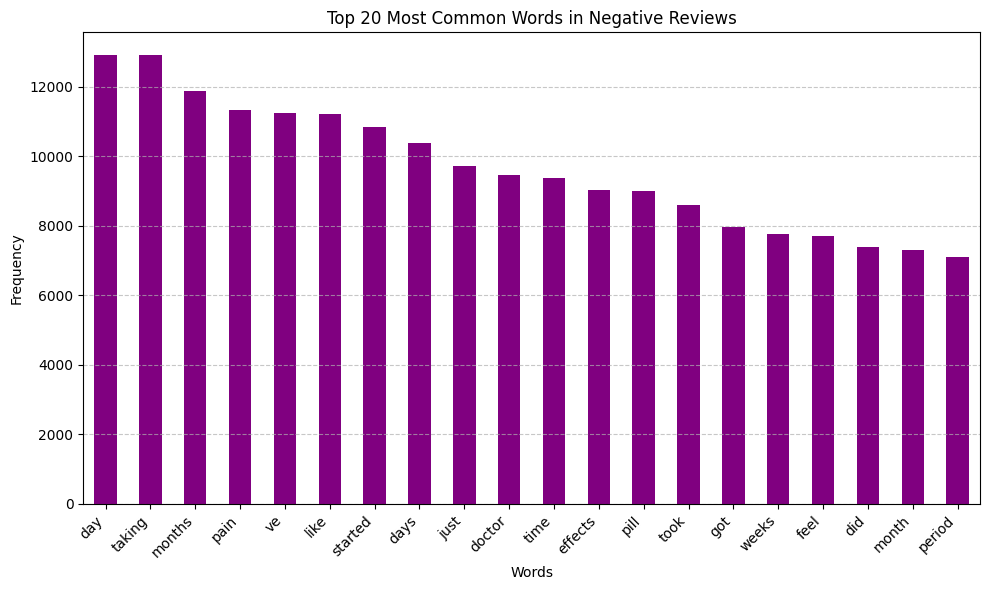

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#initialize CountVectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=20)  # 20 most common words
X_counts = vectorizer.fit_transform(negative_reviews['review_cleaned'])

#convert to DataFrame
word_freq_df = pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out())
top_words = word_freq_df.sum().sort_values(ascending=False)

print(top_words)

#visiualisation
plt.figure(figsize=(10, 6))
top_words.head(20).plot(kind='bar', color='purple')
plt.title('Top 20 Most Common Words in Negative Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top 20 TF-IDF Weighted Words in Negative Reviews
Difference:

**Top 20 Most Common Words**: Simply shows which words appear the most, even if they're generic.

**Top 20 TF-IDF Weighted Words**: Shows which words are both frequent and unique to negative reviews—highlighting the specific complaints or themes that set them apart from general chatter.

taking     0.108465
day        0.105035
pain       0.102700
months     0.099142
like       0.094598
ve         0.093418
days       0.089688
effects    0.088738
started    0.087575
just       0.085001
doctor     0.084539
took       0.084441
time       0.083765
did        0.077053
weeks      0.073782
pill       0.073228
got        0.071908
feel       0.071359
month      0.065005
period     0.057506
dtype: float64


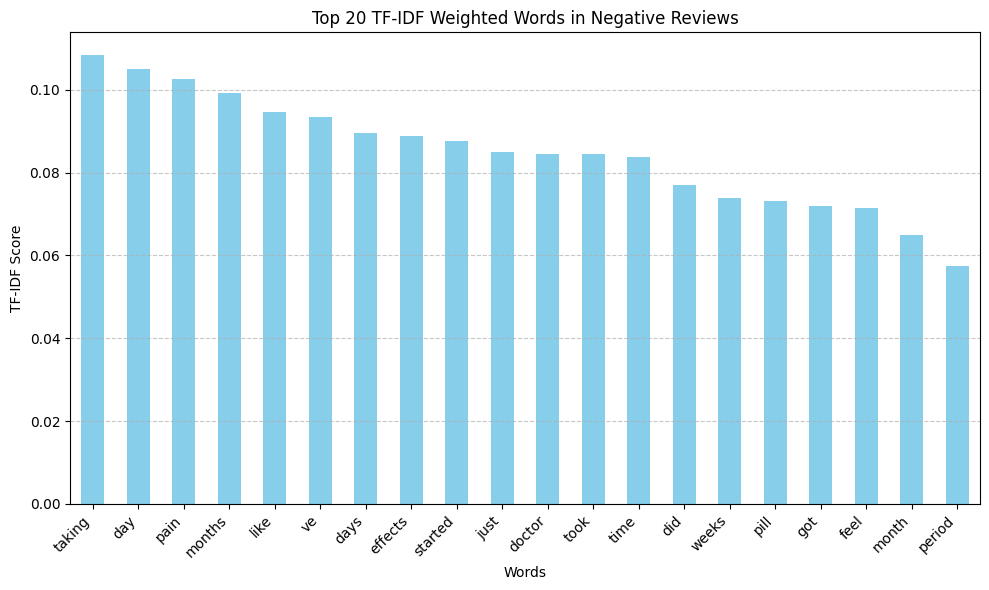

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
X_tfidf = tfidf_vectorizer.fit_transform(negative_reviews['review_cleaned'])

#convert to DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
top_tfidf_words = tfidf_df.mean().sort_values(ascending=False)

print(top_tfidf_words)

plt.figure(figsize=(10, 6))
top_tfidf_words.head(20).plot(kind='bar', color='skyblue')
plt.title('Top 20 TF-IDF Weighted Words in Negative Reviews')
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top 20 Most Common Bigrams in Negative Reviews
**Bigrams** (2 worded phrases) and **trigrams** (3 worded phrases) capture common phrases (like “birth control” or “side effects”), revealing more specific complaint patterns in the reviews. They provide a clearer picture of the actual issues being discussed, rather than isolated words.

birth control        4913
mood swings          2753
weight gain          1908
feel like            1849
sex drive            1798
felt like            1736
started taking       1560
stopped taking       1371
blood pressure       1160
don know              906
months ago            875
stop taking           861
taking pill           856
panic attacks         771
doctor prescribed     712
really bad            710
years old             692
years ago             684
yeast infection       671
doctor said           646
dtype: int64


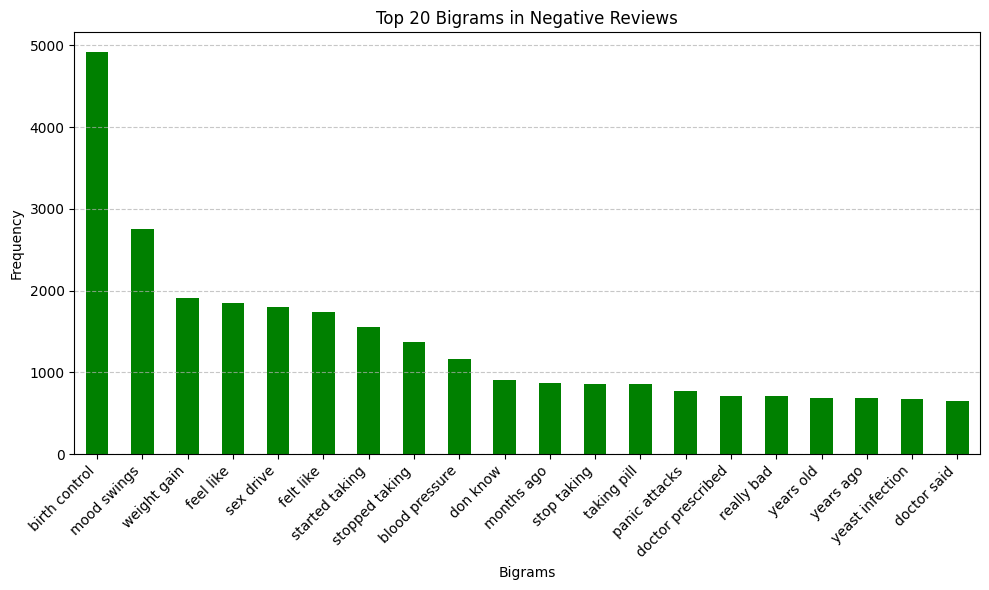

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

#initialize Bigram Vectorizer
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(negative_reviews['review_cleaned'])

#convert to DataFrame
bigram_freq_df = pd.DataFrame(X_bigrams.toarray(), columns=bigram_vectorizer.get_feature_names_out())

#sum up frequencies
top_bigrams = bigram_freq_df.sum().sort_values(ascending=False)

#display top 20 bigrams
print(top_bigrams)

plt.figure(figsize=(10, 6))
top_bigrams.plot(kind='bar', color='green')
plt.title('Top 20 Bigrams in Negative Reviews')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top 20 TF-IDF Weighted Bigrams in Negative Reviews

birth control        0.072715
mood swings          0.046442
feel like            0.034723
weight gain          0.033697
felt like            0.033473
sex drive            0.031808
started taking       0.028676
stopped taking       0.026928
blood pressure       0.019866
don know             0.018974
stop taking          0.017618
months ago           0.017257
taking pill          0.015324
doctor prescribed    0.014957
panic attacks        0.014703
really bad           0.014260
years ago            0.014029
years old            0.013757
doctor said          0.013219
yeast infection      0.013173
dtype: float64


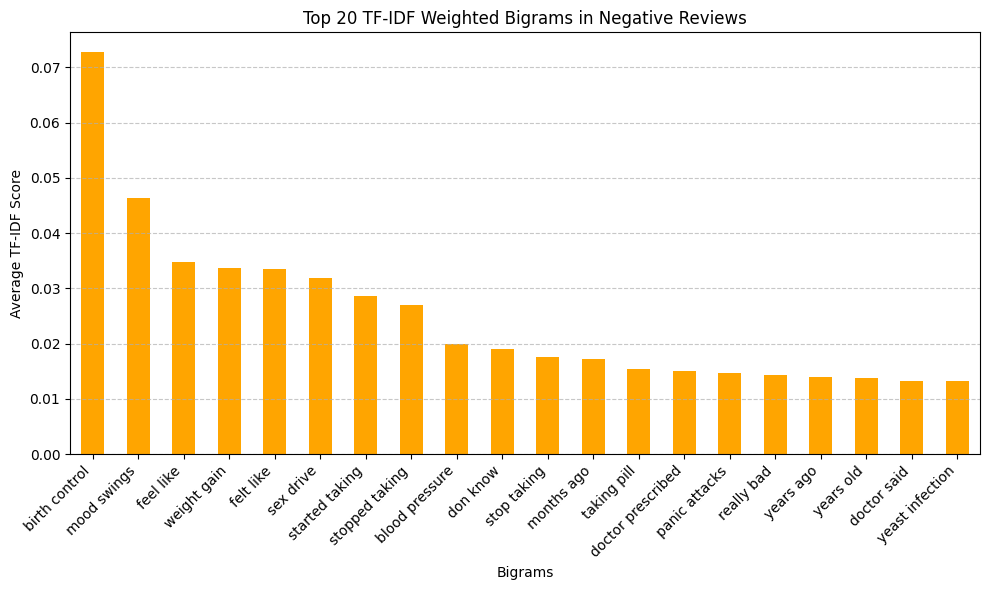

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#initialize Bigram TF-IDF Vectorizer
bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
X_bigrams_tfidf = bigram_tfidf_vectorizer.fit_transform(negative_reviews['review_cleaned'])

#convert to DataFrame
bigram_tfidf_df = pd.DataFrame(X_bigrams_tfidf.toarray(), columns=bigram_tfidf_vectorizer.get_feature_names_out())

#calculate average TF-IDF score for each bigram
top_bigrams_tfidf = bigram_tfidf_df.mean().sort_values(ascending=False)

# top 20 bigrams by TF-IDF weight
print(top_bigrams_tfidf)

plt.figure(figsize=(10, 6))
top_bigrams_tfidf.plot(kind='bar', color='orange')
plt.title('Top 20 TF-IDF Weighted Bigrams in Negative Reviews')
plt.xlabel('Bigrams')
plt.ylabel('Average TF-IDF Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top 20 Most Used Trigrams in Negative Reviews

birth control pills        252
birth control pill         238
high blood pressure        231
taking birth control       228
ortho tri cyclen           189
gained 10 pounds           178
worst birth control        173
mood swings depression     162
felt like going            157
gained 20 pounds           156
form birth control         155
anxiety panic attacks      154
horrible mood swings       153
birth control months       152
flu like symptoms          133
started taking pill        129
don feel like              126
recommend birth control    123
birth control ve           123
terrible mood swings       123
dtype: int64


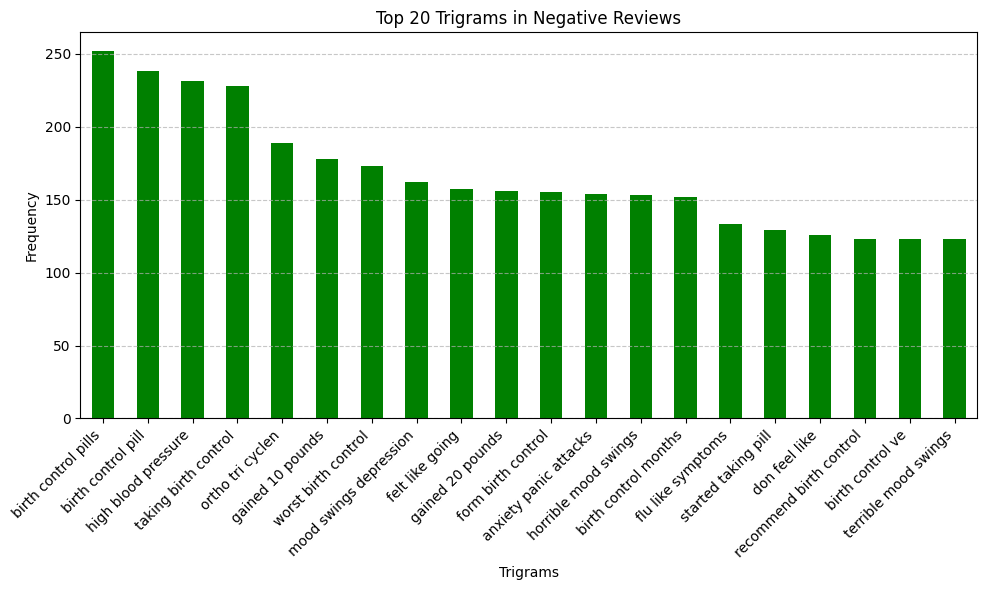

In [ ]:
def plot_top_ngrams(text_series, ngram_range=(3, 3), color='green', title='Top Trigrams'):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=20)
    X = vectorizer.fit_transform(text_series)
    freq_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
    top_ngrams = freq_df.sum().sort_values(ascending=False)
    print(top_ngrams)

    plt.figure(figsize=(10, 6))
    top_ngrams.plot(kind='bar', color=color)
    plt.title(title)
    plt.xlabel('Trigrams')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_top_ngrams(negative_reviews['review_cleaned'], ngram_range=(3, 3), color='green', title='Top 20 Trigrams in Negative Reviews')


### Topic Modeling (LDA)
Using the Latent Dirichlet Allocation (LDA) algorithm to find hidden themes (topics) in the dataset.
Each topic is a group of words that tend to appear together in documents.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

#use CountVectorizer again
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_counts = vectorizer.fit_transform(negative_reviews['review_cleaned'])

#initialize LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # 5 topics
lda.fit(X_counts)

#top words per topic
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    print(f"Topic {i+1}:")
    print([words[j] for j in top_words_idx])
    print()


Topic 1:
['effects', 'anxiety', 'taking', 'medication', 'drug', 'years', 'depression', 'months', 'started', 'doctor']

Topic 2:
['bleeding', 'period', 'months', 'got', 'month', 'days', 'weeks', 'shot', 'started', 'having']

Topic 3:
['pill', 've', 'months', 'control', 'weight', 'acne', 'birth', 'month', 'taking', 'started']

Topic 4:
['pain', 'day', 'taking', 'days', 'took', 'doctor', 'severe', 'stomach', 'started', 'medication']

Topic 5:
['like', 'day', 'night', 'just', 'sleep', 'work', 'feel', 'time', 'took', 'don']



**What Do These “Topics” Mean?**


Possible Themes:
- Topic 1:
Mental health & medication effects

- Topic 2:
Menstrual/period-related issues

- Topic 3:
Birth control side effects (acne, weight)

- Topic 4:
Pain & doctor visits

- Topic 5:
Daily discomfort, sleep issues

#### Topic Wordcloud

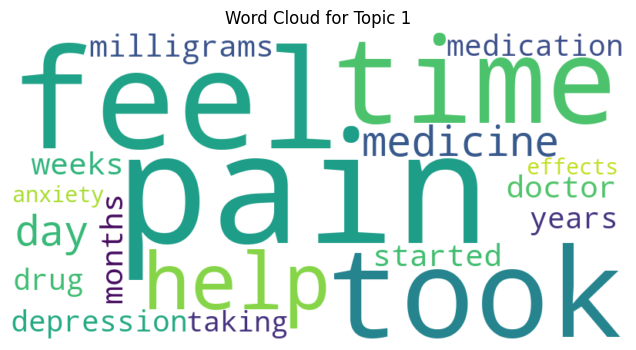

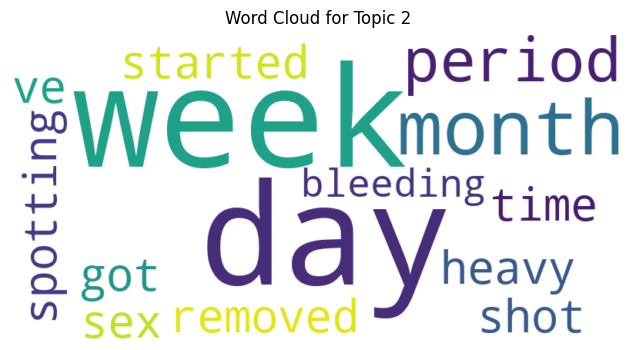

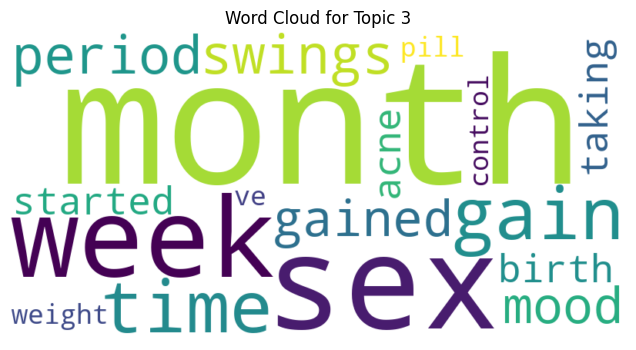

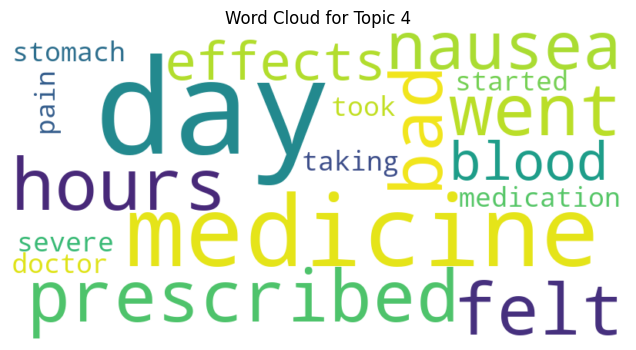

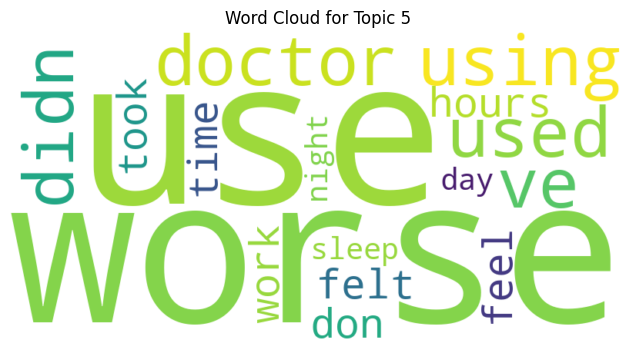

In [ ]:
from wordcloud import WordCloud

# word clouds for each topic
for i, topic in enumerate(lda.components_):
    topic_words = [words[j] for j in topic.argsort()[-20:]]
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(topic_words))
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Topic {i+1}')
    plt.show()


### Histogram of the Sentiment Polarity Distribution in the Negative Reviews



/var/folders/68/hprt_lq14j15tgjr6zxrgmch0000gn/T/ipykernel_36563/2427888261.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews.loc[:, 'polarity'] = negative_reviews['review_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)


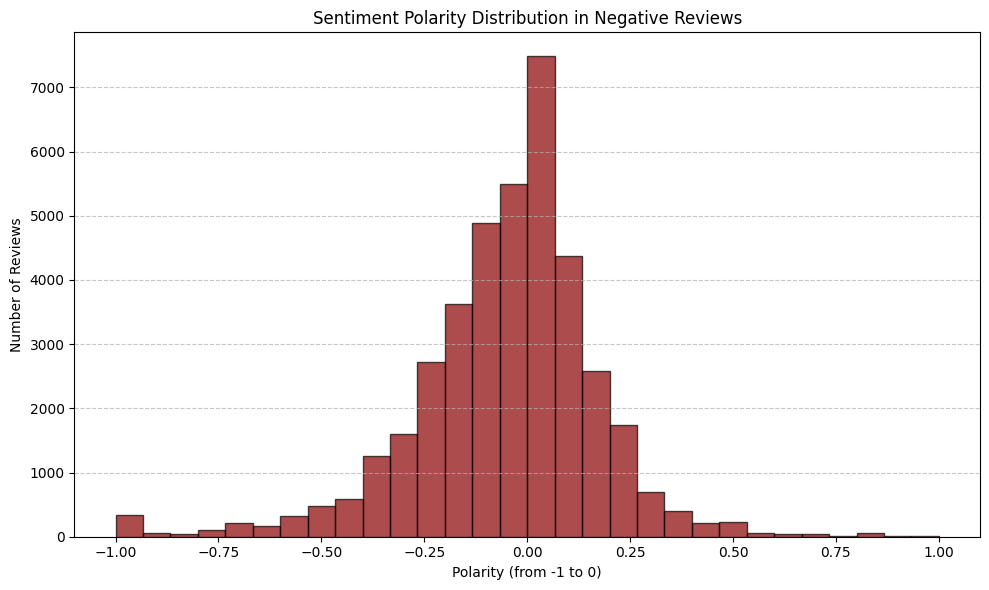

In [ ]:
from textblob import TextBlob

#calculate sentiment polarity
negative_reviews.loc[:, 'polarity'] = negative_reviews['review_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)

#visualize sentiment polarity
plt.figure(figsize=(10, 6))
plt.hist(negative_reviews['polarity'], bins=30, color='darkred', edgecolor='black', alpha=0.7)
plt.title('Sentiment Polarity Distribution in Negative Reviews')
plt.xlabel('Polarity (from -1 to 0)')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Although these are all negative reviews, there’s a range of negativity:

- Some reviews are just slightly negative (near 0)

- Others are deeply negative (closer to -1)

- A few even cross into positive (likely due to mixed experiences in a review)

